In [61]:
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid")

In [62]:
df = pd.read_csv('tested.csv').copy()
target_col = 'Survived'
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [63]:
display(df.dtypes.rename('dtype').to_frame())

,dtype
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [64]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,418.0,NaN,NaN,NaN,1100.5,120.810458,892.0,996.25,1100.5,1204.75,1309.0
Survived,418.0,NaN,NaN,NaN,0.363636,0.481622,0.0,0.0,0.0,1.0,1.0
Pclass,418.0,NaN,NaN,NaN,2.26555,0.841838,1.0,1.0,3.0,3.0,3.0
Name,418,418,"Kelly, Mr. James",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,418,2,male,266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,332.0,NaN,NaN,NaN,30.27259,14.181209,0.17,21.0,27.0,39.0,76.0
SibSp,418.0,NaN,NaN,NaN,0.447368,0.89676,0.0,0.0,0.0,1.0,8.0
Parch,418.0,NaN,NaN,NaN,0.392344,0.981429,0.0,0.0,0.0,0.0,9.0
Ticket,418,363,PC 17608,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,417.0,NaN,NaN,NaN,35.627188,55.907576,0.0,7.8958,14.4542,31.5,512.3292


In [65]:
display(df.isnull().sum().rename('missing').to_frame())

,missing
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


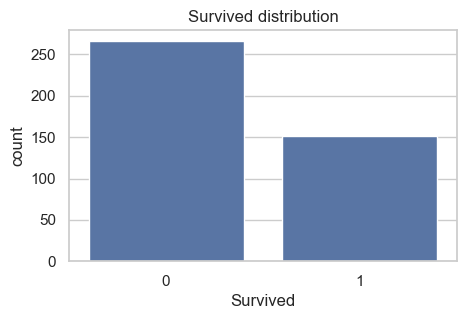

In [66]:
plt.figure(figsize=(5, 3))
sns.countplot(x=target_col, data=df)
plt.title("Survived distribution")
plt.show()

In [67]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

In [68]:
df['Age']      = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

In [69]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

In [70]:
df.isnull().sum().rename('missing')

Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
Name: missing, dtype: int64

In [71]:
df.head()


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,34.5,0,0,7.8292,True,True,False
1,1,3,47.0,1,0,7.0000,False,False,True
2,0,2,62.0,0,0,9.6875,True,True,False
3,0,3,27.0,0,0,8.6625,True,False,True
4,1,3,22.0,1,1,12.2875,False,False,True


In [72]:
df.isnull().sum()

Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

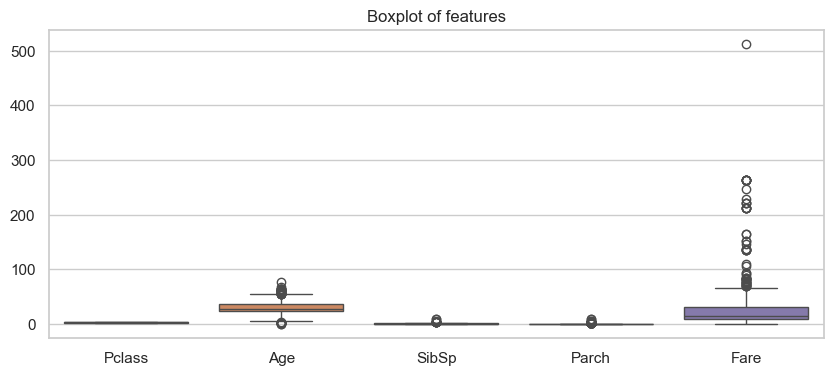

In [82]:
numeric_cols = df.drop(columns=[target_col]).select_dtypes(include=np.number).columns

plt.figure(figsize=(10, 4))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot of features")
plt.show()

In [74]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [76]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [77]:
pca = PCA(n_components=0.95)
X_train = pca.fit_transform(X_train)
X_test  = pca.transform(X_test)

In [78]:
Logistic_param = {'C': [0.01, 0.1, 1, 10]}
model_logistic = LogisticRegression(max_iter=1000, random_state=42)

KNN_param = {'n_neighbors': [3, 5, 7, 9]}
model_knn = KNeighborsClassifier()

SVM_param = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
model_svm = SVC(random_state=42)

Tree_param = {'max_depth': [3, 5, 10], 'min_samples_split': [2, 5]}
model_tree = DecisionTreeClassifier(random_state=42)

RF_param = {'n_estimators': [50, 100], 'max_depth': [3, 5, 10]}
model_rf = RandomForestClassifier(random_state=42)

In [79]:
grid_log = GridSearchCV(model_logistic, Logistic_param, cv=5, n_jobs=-1)
grid_log.fit(X_train, y_train)

grid_knn = GridSearchCV(model_knn, KNN_param, cv=5, n_jobs=-1)
grid_knn.fit(X_train, y_train)

grid_svm = GridSearchCV(model_svm, SVM_param, cv=5, n_jobs=-1)
grid_svm.fit(X_train, y_train)

grid_dt = GridSearchCV(model_tree, Tree_param, cv=5, n_jobs=-1)
grid_dt.fit(X_train, y_train)

grid_rf = GridSearchCV(model_rf, RF_param, cv=5, n_jobs=-1)
grid_rf.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'n_estimators': [50, 100]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [80]:
models = [
    ('Logistic',      grid_log),
    ('KNN',           grid_knn),
    ('SVM',           grid_svm),
    ('Decision Tree', grid_dt),
    ('Random Forest', grid_rf),
]

results = []
for name, grid in models:
    y_pred = grid.best_estimator_.predict(X_test)
    results.append({
        'Model':         name,
        'Best Params':   grid.best_params_,
        'CV Best Score': round(grid.best_score_, 4),
        'Test Accuracy': round(accuracy_score(y_test, y_pred), 4),
    })

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

,Model,Best Params,CV Best Score,Test Accuracy
0,Logistic,{'C': 0.01},1.0000,1.0000
1,SVM,"{'C': 0.1, 'kernel': 'linear'}",1.0000,1.0000
2,Random Forest,"{'max_depth': 5, 'n_estimators': 50}",0.9791,0.9762
3,KNN,{'n_neighbors': 5},0.9880,0.9643
4,Decision Tree,"{'max_depth': 10, 'min_samples_split': 2}",0.9699,0.9524


In [81]:
display(results_df.loc[[0]])

,Model,Best Params,CV Best Score,Test Accuracy
0,Logistic,{'C': 0.01},1.0,1.0
